<!-- reader-content -->

# A resonator measurement with accumulated noise

A VNA probe drives a resonator through a circulator. The returning field passes
through an isolator, a matched absorptive filter, and a HEMT. Capture the
stationary mean and noise once, then compare receiver integration times using
the same measurement.

## Declare the resonator and readout line

Frequencies are in GHz, decay rates in `1/ns`, integration times in ns, and
field amplitudes in `1/sqrt(ns)`. The HEMT has power gain 100 and input-referred
symmetrized added noise of four quanta. The filter's `loss_occupation` declares
a matched absorptive realization; a transmission curve alone does not specify
thermal emission from a reflecting filter.

In [1]:
import numpy as np
from quchip import Chip, IQReceiver, PortNetwork, Resonator, VNA, qnp

r = Resonator(freq=6.0, levels=8, T1=200, label="r")
network = PortNetwork(label="readout_line")
coupler = network.port("coupler", target=r, rate=0.04)
circulator = network.circulator("circulator")
isolator = network.isolator("isolator", occupation=0.02)


def passband(frequency, center, width, eta):
    return qnp.sqrt(eta) / (1 - 1j * (frequency - center) / width)


filter_section = network.filter(
    "filter", transfer=passband, center=6.0, width=0.02, eta=0.8,
    loss_occupation=0.05,
)
hemt = network.amplifier("hemt", gain=100.0, added_noise=4.0)
network.link(coupler, circulator.side(2))
network.link(circulator.side(3), isolator, filter_section, hemt)
drive = network.expose("drive", at=circulator.side(1))
readout = network.expose("readout", at=hemt.side(2))
chip = Chip([r], port_network=network)
frequencies = np.linspace(5.988, 6.012, 121)

## Capture once, choose the receiver afterward

`measure()` performs a finite-power stationary calculation at every probe
frequency and stores physical noise spectra. The mean and fluctuations use
the same operating point. `sample()` integrates the stored spectra and draws
joint Gaussian IQ samples without calling a simulator again.

In [2]:
measurement = VNA(chip).measure(frequencies, amplitudes=0.02, input=drive, outputs=[readout])
short = measurement.sample(1, receiver=IQReceiver(integration_time=200_000), seed=7)
long = measurement.sample(1, receiver=IQReceiver(integration_time=2_000_000), seed=7)

The two draws use the same random seed so their difference shows the effect
of integration time. The deterministic curve includes the declared network's
loss and phase. Dividing by the known HEMT amplitude gain of ten makes the
resonator response easier to compare; this is an explicit gain calibration.

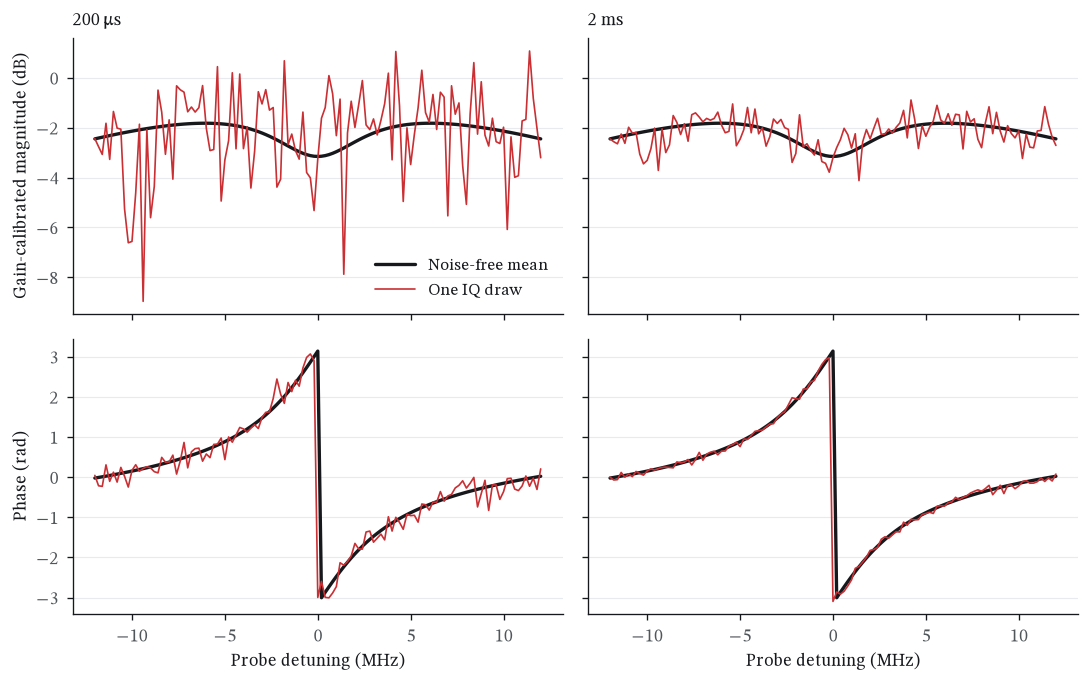

In [3]:
import matplotlib.pyplot as plt
from pathlib import Path

root = Path.cwd() if (Path.cwd() / "quchip").exists() else Path.cwd().parent
plt.style.use(root / "docs/_static/quchip.mplstyle")
ideal = measurement.ratio(readout) / 10
short_ratio = short.ratio(readout)[0] / 10
long_ratio = long.ratio(readout)[0] / 10
fig, axes = plt.subplots(2, 2, figsize=(9.2, 5.8), sharex=True, sharey="row")
detuning = (frequencies - r.freq) * 1000
for column, (observed, title) in enumerate(((short_ratio, "200 µs"), (long_ratio, "2 ms"))):
    axes[0, column].plot(detuning, 20*np.log10(np.abs(ideal)), color="#16181C", label="Noise-free mean")
    axes[0, column].plot(detuning, 20*np.log10(np.abs(observed)), color="#C92F33", lw=1, label="One IQ draw")
    axes[1, column].plot(detuning, np.angle(ideal), color="#16181C")
    axes[1, column].plot(detuning, np.angle(observed), color="#C92F33", lw=1)
    axes[0, column].set_title(title)
    axes[1, column].set_xlabel("Probe detuning (MHz)")
axes[0, 0].set_ylabel("Gain-calibrated magnitude (dB)")
axes[1, 0].set_ylabel("Phase (rad)")
axes[0, 0].legend(frameon=False)
fig.tight_layout()
fig.savefig(root / "docs/images/noisy-vna-measurement.svg")
plt.show()

```{figure} ../images/noisy-vna-measurement.svg
:class: only-light
:alt: Resonator magnitude and phase, comparing the deterministic mean with sampled IQ at 200 microseconds and 2 milliseconds.
```

```{figure} ../images/noisy-vna-measurement-dark.svg
:class: only-dark
:alt: Resonator magnitude and phase, comparing the deterministic mean with sampled IQ at 200 microseconds and 2 milliseconds.
```

## Inspect the covariance and source budget

Calibration transforms both the field mean and covariance. The detector adds
one vacuum quantum to the complex normally ordered spectrum at the detection
plane. In the flat circular case, each IQ variance is `(N + 1)/(2*T)`.

In [4]:
statistics = measurement.statistics(receiver=IQReceiver(integration_time=200_000))
calibrated = statistics.calibrate({readout: 0.1})
budget = calibrated.noise_contributions(readout)
center = len(frequencies) // 2
print(f"RESULT center_I_variance={calibrated.covariance(readout)[center, 0, 0]:.10f}")
print(f"RESULT short_IQ_rmse={np.sqrt(np.mean(np.abs(short_ratio-ideal)**2)):.8f}")
print(f"RESULT long_IQ_rmse={np.sqrt(np.mean(np.abs(long_ratio-ideal)**2)):.8f}")

RESULT center_I_variance=0.0000112874
RESULT short_IQ_rmse=0.21578512
RESULT long_IQ_rmse=0.06823724


`device.correlations` contains device-generated excess noise and interference
with incident thermal fields. It can be negative for squeezed light. Directly
propagated load and amplifier contributions retain their source labels. The
budget's sum is the full integrated covariance, including `receiver.vacuum`.

The default stored offset grid spans ±0.1 GHz with logarithmic spacing down to
1 Hz. Supply `noise_frequencies=` to resolve other noise features. Receiver
processing checks quadrature convergence and edge support on the captured
grid; it cannot detect a spectral feature that was never sampled. Inspect a
concrete result when differentiating, because host validation cannot run
inside a JAX trace. Physical network changes require another measurement.

## Cascade a second amplifier after loss

A physical component between amplifiers changes both signal and noise. For
power gains `G1`, `G2` and intermediate transmission `eta`, the first
amplifier's added noise reaches the output multiplied by `eta*G2`.

In [5]:
cascade = PortNetwork(label="cascade")
p = cascade.port("p", target=r, rate=0.04)
a = cascade.amplifier("first", gain=100.0, added_noise=1.0)
loss = cascade.attenuator("loss", eta=0.25, occupation=0.2)
b = cascade.amplifier("second", gain=10.0, added_noise=2.0)
cascade.link(p, a, loss, b)
out = cascade.expose("out", at=b.side(2))
cascaded = VNA(Chip([r], port_network=cascade)).measure(6.0, 0.0, input=out, outputs=[out])
noise = cascaded.noise_contributions(out)
expected_added = 10*(0.25*149.5 + 0.75*0.2) + 24.5
direct_added = sum(np.trace(value[len(cascaded.noise_frequencies)//2]).real
                   for name, value in noise.items() if name.startswith("output."))
np.testing.assert_allclose(direct_added, expected_added)
print(f"RESULT cascade_direct_added_noise={direct_added:.8f}")

RESULT cascade_direct_added_noise=399.75000000


The attenuator also emits toward the chip through its reverse traversal. That
thermal input changes the stationary state and its correlations; it is
included separately from the displayed forward added-noise formula.

## Let a warm isolator load reach the resonator

An ideal isolator passes side 1 to side 2, sends side 2 into its load, and
emits from the load toward side 1. A warm load facing a resonator therefore
heats it even with no coherent input. Temperature declarations use mK and
require a physical `noise_frequency` in GHz, independently of rotating frames.

In [6]:
warm_line = PortNetwork(label="warm_line")
p = warm_line.port("p", target=r, rate=0.04)
iso = warm_line.isolator("iso", temperature=100.0, noise_frequency=6.0)
warm_line.link(p, iso)
plane = warm_line.expose("out", at=iso.side(2))
warm_chip = Chip([r], port_network=warm_line)
thermal_measurement = VNA(warm_chip).measure(6.0, 0.0, input=plane, outputs=[plane])
warm_spectrum = sum(thermal_measurement.noise_contributions(plane).values())
warm_center = np.trace(warm_spectrum[len(thermal_measurement.noise_frequencies)//2]).real
print(f"RESULT warm_center_normal_noise={warm_center:.10f}")

RESULT warm_center_normal_noise=0.0359949808


These samples use a Gaussian approximation based on second moments. Squeezed
and cross-output covariances are retained, but nonlinear photon statistics,
quantum trajectories, and time-correlated acquisition records are not inferred
from a spectrum. Reference filters evaluate exact stationary sideband transfers;
transient filters still use the carrier approximation. Colored noise feeding
a quantum coupling requires an explicit dynamical filter/bath model.